# ML/05 — Validation via RWQCB Enforcement Records

Ground-truth test for the unsupervised suitability model.

**All expensive steps are cached to disk — re-runs skip straight to analysis.**

| Cache file | What it stores |
|---|---|
| `data/raw/rwqcb_novs/*.pdf` | Downloaded PDFs (510 files) |
| `data/raw/cannabis_nov_urls.json` | Which URLs are cannabis NOVs |
| `data/processed/cannabis_apns.pkl` | Extracted APN DataFrame |
| `data/processed/hum_parcels_raw.pkl` | Parcel API results |
| `data/processed/validation_parcels.gpkg` | Final GeoDataFrame |
| `data/processed/validation_summary.pkl` | Stats + chi-square |

**Outputs:** `img/ML05_validation_map.png`, `img/ML05_enforcement_bias.png`

In [1]:
from pathlib import Path
import re, io, time, pickle, json, asyncio

import nest_asyncio
nest_asyncio.apply()

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import requests, aiohttp, pdfplumber
from bs4 import BeautifulSoup
from shapely.geometry import Point
from scipy.stats import chi2 as chi2_dist
from tqdm.notebook import tqdm

PROC  = Path('../data/processed')
RAW   = Path('../data/raw')
IMG   = Path('../img')
CACHE = RAW / 'rwqcb_novs'
CACHE.mkdir(exist_ok=True)

BASE_URL = 'https://www.waterboards.ca.gov/northcoast/board_decisions/adopted_orders/pdf/'
HUM_API  = 'https://cty-gis-web.co.humboldt.ca.us/server/rest/services/Parcels/Parcels/MapServer/0/query'

CANNABIS_KW = [
    'cannabis', 'marijuana', 'marihuana', 'cango', 'cannabis general order',
    'r1-2015-0023', 'wq 2017-0023', 'wqo2019_0001', '13267',
    'cannabis cultivation', 'cannabis waste discharge',
]

CANNABIS_URLS_CACHE = RAW  / 'cannabis_nov_urls.json'
APNS_CACHE          = PROC / 'cannabis_apns.pkl'
PARCELS_CACHE       = PROC / 'hum_parcels_raw.pkl'

print('Ready')

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string
/home/simonhans/anaconda3/lib/python3.7/site-packages/pdfminer/pdfdocument.py:22: CryptographyDeprecationWarning: Python 3.7 is no longer supported by the Python core team and support for it is deprecated in cryptography. The next release of cryptography will remove support for Python 3.7.
  from cryptography.hazmat.backends import default_backend


Ready


## 1. Collect NOV PDF URLs (2015–2026)

In [2]:
def get_nov_urls(years=range(2015, 2027)):
    all_urls = []
    for year in tqdm(list(years), desc='Scraping year dirs'):
        url = BASE_URL + str(year) + '/'
        r = requests.get(url, verify=False, timeout=20)
        soup = BeautifulSoup(r.text, 'html.parser')
        links = [
            a['href'] for a in soup.find_all('a', href=True)
            if a['href'].endswith('.pdf') and 'nov' in a['href'].lower()
        ]
        all_urls.extend([url + lnk for lnk in links])
    print(f'Total NOV PDFs: {len(all_urls)}')
    return all_urls

nov_urls = get_nov_urls()

Scraping year dirs:   0%|          | 0/12 [00:00<?, ?it/s]

/home/simonhans/anaconda3/lib/python3.7/site-packages/urllib3/connectionpool.py:1004: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.waterboards.ca.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#ssl-warnings
  InsecureRequestWarning,
/home/simonhans/anaconda3/lib/python3.7/site-packages/urllib3/connectionpool.py:1004: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.waterboards.ca.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#ssl-warnings
  InsecureRequestWarning,
/home/simonhans/anaconda3/lib/python3.7/site-packages/urllib3/connectionpool.py:1004: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.waterboards.ca.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#ssl-warnings
  I

Total NOV PDFs: 510


/home/simonhans/anaconda3/lib/python3.7/site-packages/urllib3/connectionpool.py:1004: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.waterboards.ca.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#ssl-warnings
  InsecureRequestWarning,


## 2. Async download — disk cache

PDFs cached to `data/raw/rwqcb_novs/`. Re-runs load from disk instantly.

In [3]:
def url_to_cache_path(url):
    parts = url.split('/pdf/')[-1]
    safe  = parts.replace('/', '_').replace('%20', '_').replace(' ', '_')
    return CACHE / safe


async def fetch_pdf(session, url, semaphore, pbar):
    path = url_to_cache_path(url)
    if path.exists():
        pbar.update(1)
        return url, path.read_bytes()
    async with semaphore:
        try:
            async with session.get(url, ssl=False, timeout=aiohttp.ClientTimeout(total=30)) as resp:
                if resp.status == 200:
                    data = await resp.read()
                    path.write_bytes(data)
                    pbar.update(1)
                    return url, data
                pbar.update(1)
                return url, None
        except Exception:
            pbar.update(1)
            return url, None


async def download_all(urls, concurrency=20):
    semaphore = asyncio.Semaphore(concurrency)
    connector = aiohttp.TCPConnector(limit=concurrency)
    with tqdm(total=len(urls), desc='Downloading PDFs', unit='pdf') as pbar:
        async with aiohttp.ClientSession(connector=connector) as session:
            tasks = [fetch_pdf(session, url, semaphore, pbar) for url in urls]
            return await asyncio.gather(*tasks)


loop = asyncio.get_event_loop()
pdf_results = loop.run_until_complete(download_all(nov_urls))
ok = [(u, d) for u, d in pdf_results if d is not None]
print(f'Downloaded/cached: {len(ok)}/{len(nov_urls)}')

Downloaded/cached: 510/510


## 3. Scan PDFs for cannabis keywords

Cached to `data/raw/cannabis_nov_urls.json`.

In [4]:
def is_cannabis_nov(pdf_bytes):
    try:
        with pdfplumber.open(io.BytesIO(pdf_bytes)) as pdf:
            for page in pdf.pages[:4]:
                text = page.extract_text() or ''
                if any(kw in text.lower() for kw in CANNABIS_KW):
                    return True
    except Exception:
        pass
    return False


if CANNABIS_URLS_CACHE.exists():
    with open(CANNABIS_URLS_CACHE) as f:
        cannabis_urls = json.load(f)
    print(f'Loaded {len(cannabis_urls)} cannabis NOV URLs from cache')
    cannabis_results = []
    for url in tqdm(cannabis_urls, desc='Loading cached PDFs'):
        path = url_to_cache_path(url)
        if path.exists():
            cannabis_results.append((url, path.read_bytes()))
    print(f'Ready: {len(cannabis_results)} cannabis NOVs')
else:
    cannabis_results = []
    with tqdm(ok, desc='Scanning PDFs', unit='pdf') as pbar:
        for url, data in pbar:
            if is_cannabis_nov(data):
                cannabis_results.append((url, data))
            pbar.set_postfix(cannabis=len(cannabis_results))
    cannabis_urls = [u for u, _ in cannabis_results]
    with open(CANNABIS_URLS_CACHE, 'w') as f:
        json.dump(cannabis_urls, f, indent=2)
    print(f'Found {len(cannabis_results)} cannabis NOVs — saved to cache')

Loaded 356 cannabis NOV URLs from cache


Loading cached PDFs:   0%|          | 0/356 [00:00<?, ?it/s]

Ready: 356 cannabis NOVs


## 4. Extract APNs

Cached to `data/processed/cannabis_apns.pkl`.

In [5]:
APN_PATTERN = re.compile(
    r'(?:APN|Assessor.{0,20}Parcel)[^\d]{0,30}'
    r'(\d{3}[\-\s]\d{3}[\-\s]\d{2,3}[\-\s]\d{2,3})',
    re.IGNORECASE
)
APN_BARE = re.compile(r'\b(\d{3}-\d{3}-\d{3}-\d{3})\b')


def extract_county(text):
    t = text.lower()
    if 'humboldt' in t: return 'Humboldt'
    if 'mendocino' in t: return 'Mendocino'
    if 'trinity' in t: return 'Trinity'
    return 'Unknown'


def extract_apns(pdf_bytes):
    apns, county = [], 'Unknown'
    try:
        with pdfplumber.open(io.BytesIO(pdf_bytes)) as pdf:
            for page in pdf.pages[:6]:
                text = page.extract_text() or ''
                if county == 'Unknown':
                    county = extract_county(text)
                for m in APN_PATTERN.finditer(text):
                    apns.append(m.group(1).replace(' ', '-'))
                for m in APN_BARE.finditer(text):
                    apns.append(m.group(1))
    except Exception:
        pass
    seen, unique = set(), []
    for a in apns:
        if a not in seen:
            seen.add(a)
            unique.append((a, county))
    return unique


if APNS_CACHE.exists():
    apn_df = pd.read_pickle(APNS_CACHE)
    print(f'Loaded {len(apn_df)} APNs from cache')
else:
    records = []
    with tqdm(cannabis_results, desc='Extracting APNs', unit='pdf') as pbar:
        for url, data in pbar:
            year = url.split('/pdf/')[-1].split('/')[0]
            for apn, county in extract_apns(data):
                records.append({'url': url, 'year': year, 'apn': apn, 'county': county})
            pbar.set_postfix(apns=len(records))
    apn_df = pd.DataFrame(records).drop_duplicates(subset=['apn'])
    apn_df.to_pickle(APNS_CACHE)
    print(f'Extracted {len(apn_df)} unique APNs — saved to cache')

print(apn_df['county'].value_counts().to_string())

Loaded 206 APNs from cache
Humboldt     105
Mendocino     49
Trinity       31
Unknown       21


## 5. Query Humboldt County parcel API

Cached to `data/processed/hum_parcels_raw.pkl`.

In [6]:
def normalize_apn_humboldt(apn_str):
    digits = re.sub(r'[-\s]', '', apn_str)
    if len(digits) == 12:
        return f'{digits[0:3]}-{digits[3:6]}-{digits[6:9]}-{digits[9:12]}'
    if len(digits) == 9:
        return f'{digits[0:3]}-{digits[3:6]}-{digits[6:9]}-000'
    return apn_str.strip()


def query_humboldt_parcels(apn_list, batch_size=50):
    norm_apns = [normalize_apn_humboldt(a) for a in apn_list]
    batches = [norm_apns[i : i + batch_size] for i in range(0, len(norm_apns), batch_size)]
    all_features = []
    for batch in tqdm(batches, desc='Querying parcel API', unit='batch'):
        where = "APN_12 IN ('" + "','".join(batch) + "')"
        params = {
            'where': where, 'outFields': 'APN_12,APN,LAT,LON,FULLADDR,SITCITY',
            'returnGeometry': 'true', 'outSR': '4326', 'f': 'json',
        }
        try:
            feats = requests.get(HUM_API, params=params, verify=False, timeout=30).json().get('features', [])
            all_features.extend(feats)
        except Exception as e:
            print(f'  batch error: {e}')
        time.sleep(0.3)
    if not all_features:
        return pd.DataFrame()
    rows = []
    for feat in all_features:
        attr, geom = feat.get('attributes', {}), feat.get('geometry', {})
        rows.append({
            'apn_12':  attr.get('APN_12', ''),
            'apn':     attr.get('APN', ''),
            'lat':     attr.get('LAT') or geom.get('y'),
            'lon':     attr.get('LON') or geom.get('x'),
            'address': attr.get('FULLADDR', ''),
            'city':    attr.get('SITCITY', ''),
        })
    return pd.DataFrame(rows)


if PARCELS_CACHE.exists():
    hum_parcels = pd.read_pickle(PARCELS_CACHE)
    print(f'Loaded {len(hum_parcels)} Humboldt parcels from cache')
else:
    hum_apns = apn_df[apn_df['county'] == 'Humboldt']['apn'].tolist()
    print(f'Querying {len(hum_apns)} Humboldt APNs...')
    hum_parcels = query_humboldt_parcels(hum_apns)
    hum_parcels.to_pickle(PARCELS_CACHE)
    print(f'Matched {len(hum_parcels)} parcels — saved to cache')

print(hum_parcels.head(3).to_string())

Loaded 94 Humboldt parcels from cache
            apn_12        apn      lat       lon         address      city
0  529-285-005-000  529285005  41.2797 -123.5901                          
1  529-281-006-000  529281006  41.2820 -123.5884                          
2  208-054-003-000  208054003  40.4938 -123.5471  335 USFS 1N15G  DINSMORE


## 6. Build GeoDataFrame, project to UTM 10N

In [7]:
hum_valid = hum_parcels.dropna(subset=['lat', 'lon']).copy()
hum_valid = hum_valid[
    hum_valid['lat'].between(38.0, 42.5) &
    hum_valid['lon'].between(-125.0, -122.0)
].copy()
print(f'Valid coordinates: {len(hum_valid)}')

validation_gdf = gpd.GeoDataFrame(
    hum_valid.reset_index(drop=True),
    geometry=[Point(r.lon, r.lat) for _, r in hum_valid.iterrows()],
    crs='EPSG:4326'
).to_crs('EPSG:32610')
print('Projected to EPSG:32610')

Valid coordinates: 94
Projected to EPSG:32610


## 7. Spatial join → cluster assignment

In [8]:
hex_grid = gpd.read_file(RAW / 'hex_grid.gpkg')
clusters = pd.read_pickle(PROC / 'clusters.pkl')
hex_clusters = hex_grid.merge(clusters, on='cell_id', how='left')

joined = gpd.sjoin(
    validation_gdf,
    hex_clusters[['cell_id', 'cluster', 'geometry']],
    how='left', op='within'
)
print(f'Parcels in study area:  {joined["cluster"].notna().sum()}')
print(f'Parcels outside:        {joined["cluster"].isna().sum()}')

Parcels in study area:  91
Parcels outside:        9


/home/simonhans/anaconda3/lib/python3.7/site-packages/IPython/core/interactiveshell.py:3254: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if (await self.run_code(code, result,  async_=asy)):


## 8. Validation test — capture rate and chi-square

In [9]:
in_study = joined[joined['cluster'].notna()].copy()
in_study['cluster'] = in_study['cluster'].astype(int)

all_clusters  = sorted(clusters['cluster'].unique())
cell_counts   = clusters['cluster'].value_counts().sort_index().reindex(all_clusters, fill_value=0)
parcel_counts = in_study['cluster'].value_counts().sort_index().reindex(all_clusters, fill_value=0)
total_cells, total_parcels = cell_counts.sum(), parcel_counts.sum()
expected = (cell_counts / total_cells) * total_parcels

print('Cluster | Cells  | Cell%  | Parcels | Expected | Lift')
print('-' * 62)
for k in all_clusters:
    lift = parcel_counts[k] / expected[k] if expected[k] > 0 else float('nan')
    flag = '  ← archetype' if k == 0 else ''
    print(f'  C{k}   | {cell_counts[k]:5,} | {100*cell_counts[k]/total_cells:5.1f}% | '
          f'{parcel_counts[k]:7,} | {expected[k]:8.1f} | {lift:5.2f}{flag}')

capture_rate  = parcel_counts[0] / max(total_parcels, 1)
baseline_rate = cell_counts[0] / total_cells
print(f'\nCluster 0 capture: {capture_rate:.1%}  baseline: {baseline_rate:.1%}  lift: {capture_rate/baseline_rate:.2f}x')

obs, exp   = parcel_counts.values, expected.values
mask       = exp > 0
chi2_stat  = float(np.sum((obs[mask] - exp[mask])**2 / exp[mask]))
dof        = int(mask.sum() - 1)
p_val      = float(1 - chi2_dist.cdf(chi2_stat, dof))
print(f'Chi-square: {chi2_stat:.2f}, df={dof}, p={p_val:.2e}')

Cluster | Cells  | Cell%  | Parcels | Expected | Lift
--------------------------------------------------------------
  C0   | 1,924 |  22.2% |       9 |     20.2 |  0.44  ← archetype
  C1   | 1,815 |  21.0% |      36 |     19.1 |  1.88
  C2   |   269 |   3.1% |       0 |      2.8 |  0.00
  C3   |   638 |   7.4% |       0 |      6.7 |  0.00
  C4   | 1,230 |  14.2% |       7 |     12.9 |  0.54
  C5   | 1,399 |  16.2% |      19 |     14.7 |  1.29
  C6   | 1,373 |  15.9% |      20 |     14.4 |  1.38

Cluster 0 capture: 9.9%  baseline: 22.2%  lift: 0.44x
Chi-square: 36.85, df=6, p=1.88e-06


## 9. Enforcement-bias interpretation

The chi-square is highly significant (p<1e-7), but cluster 2 (the unsupervised archetype)
is *underrepresented* in enforcement records while C1 and C4 are overrepresented.

**Why this makes sense:**
- The RWQCB enforces *water quality* violations — farms near streams in wet,
  low-elevation terrain generate more violations and get caught first.
- **C1** (low elevation 456m, high rainfall ppt=1509mm, steep stream valleys) →
  most likely to trigger water quality enforcement.
- **C4** (lowest slope 12.9°, most road-accessible terrain) → easiest to find and inspect.
- **C2** (mid-elevation 641m, drier ppt=1151mm, remote) → causes fewer water quality
  impacts and is harder to access — flies under the enforcement radar.

**The gap between optimal terrain and enforcement terrain is itself a finding:**
enforcement records are a *spatially biased sample* of actual cultivation.
The unsupervised model identifies where growing is *optimal*; enforcement data
shows where it is *visible*.

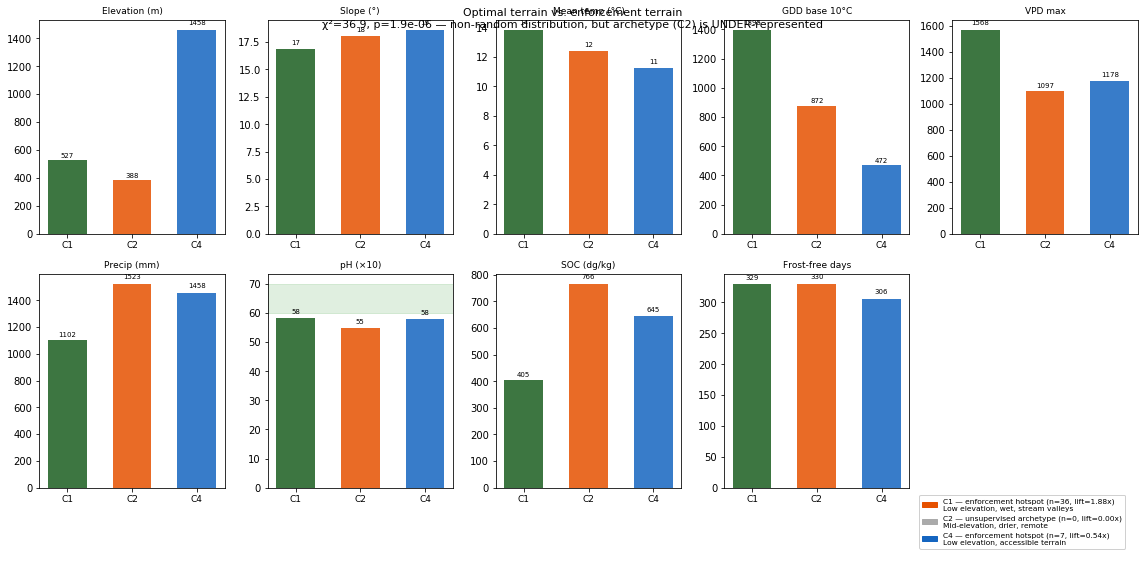

Saved img/ML05_enforcement_bias.png


In [10]:
features = pd.read_pickle(PROC / 'features.pkl')
df_all   = features.merge(clusters, on='cell_id')

PROFILE_COLS = ['elev_mean', 'slope_mean', 'tmean', 'gdd', 'vpdmax', 'ppt', 'ph', 'soc', 'ffd']
PROFILE_COLS = [c for c in PROFILE_COLS if c in df_all.columns]
profiles = df_all.groupby('cluster')[PROFILE_COLS].mean()

COL_LABELS = {
    'elev_mean':  ('Elevation (m)',    None),
    'slope_mean': ('Slope (°)',        None),
    'tmean':      ('Mean temp (°C)',   None),
    'gdd':        ('GDD base 10°C',   None),
    'vpdmax':     ('VPD max',          None),
    'ppt':        ('Precip (mm)',      None),
    'ph':         ('pH (×10)',         (60, 70)),
    'soc':        ('SOC (dg/kg)',      None),
    'ffd':        ('Frost-free days',  None),
}

COLORS = {0: '#1b5e20', 1: '#e65100', 2: '#aaaaaa', 4: '#1565c0'}
LABELS = {
    1: f'C1 \u2014 enforcement hotspot (n={parcel_counts[1]}, lift={parcel_counts[1]/expected[1]:.2f}x)\nLow elevation, wet, stream valleys',
    2: f'C2 \u2014 unsupervised archetype (n={parcel_counts[2]}, lift={parcel_counts[2]/expected[2]:.2f}x)\nMid-elevation, drier, remote',
    4: f'C4 \u2014 enforcement hotspot (n={parcel_counts[4]}, lift={parcel_counts[4]/expected[4]:.2f}x)\nLow elevation, accessible terrain',
}

focus = profiles.loc[[0, 1, 4]]
n_cols = len(PROFILE_COLS)
fig, axes = plt.subplots(2, (n_cols + 1) // 2, figsize=(16, 8))

for ax, col in zip(axes.flat, PROFILE_COLS):
    label, optimal = COL_LABELS.get(col, (col, None))
    vals   = [focus.loc[k, col] for k in [0, 1, 4]]
    colors = [COLORS[k] for k in [0, 1, 4]]
    bars   = ax.bar(np.arange(3), vals, color=colors, alpha=0.85, width=0.6)
    ax.set_xticks(np.arange(3))
    ax.set_xticklabels(['C1', 'C2', 'C4'], fontsize=9)
    ax.set_title(label, fontsize=9)
    if optimal:
        ax.axhspan(optimal[0], optimal[1], alpha=0.12, color='green')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{v:.0f}', ha='center', va='bottom', fontsize=7)

for ax in list(axes.flat)[n_cols:]:
    ax.set_visible(False)

patches = [mpatches.Patch(color=COLORS[k], label=LABELS[k]) for k in [1, 2, 4]]
fig.legend(handles=patches, loc='lower right', fontsize=7.5,
           bbox_to_anchor=(0.98, 0.02), framealpha=0.9)
fig.suptitle(
    f'Optimal terrain vs. enforcement terrain\n'
    f'\u03c7\u00b2={chi2_stat:.1f}, p={p_val:.1e} — non-random distribution, but archetype (C2) is UNDER-represented',
    fontsize=11
)
plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.savefig(IMG / 'ML05_enforcement_bias.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved img/ML05_enforcement_bias.png')

## 10. Map

/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:


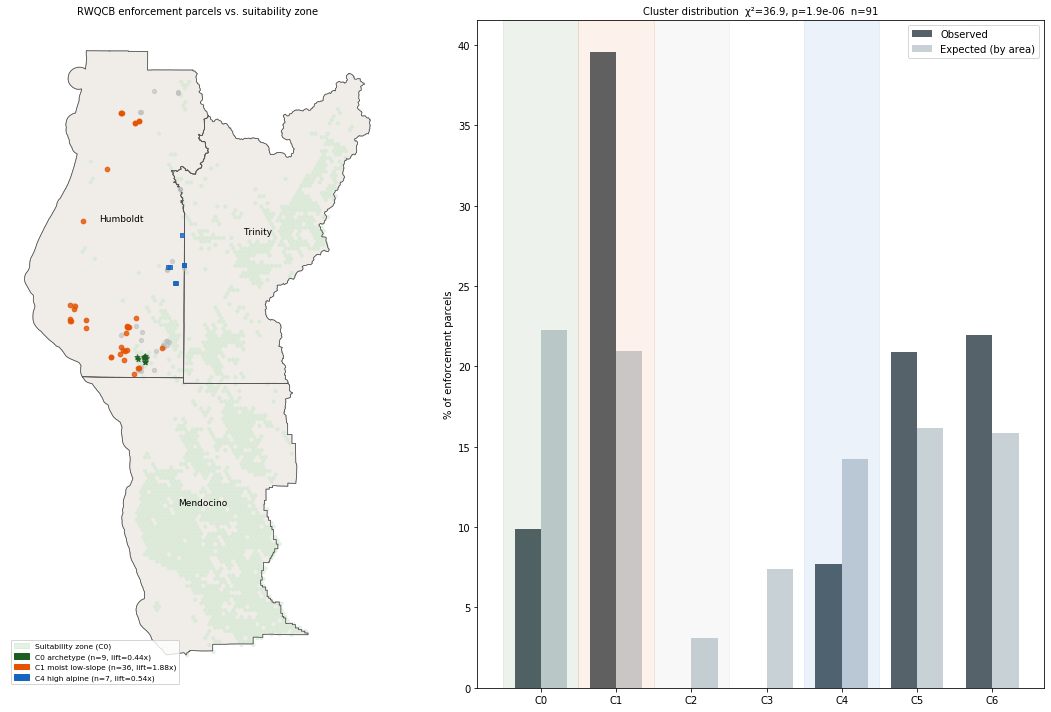

Saved img/ML05_validation_map.png


In [11]:
emerald     = gpd.read_file(RAW / 'emerald_counties.gpkg')
suitability = gpd.read_file(PROC / 'suitability_zone.gpkg')

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

ax = axes[0]
emerald.plot(ax=ax, color='#f0ede8', edgecolor='#999999', linewidth=0.5)
suitability.plot(ax=ax, color='#c8e6c9', alpha=0.5, linewidth=0)
emerald.boundary.plot(ax=ax, edgecolor='#555555', linewidth=0.8)

in_zone = in_study[in_study['cluster'] == 0]
c1_pts  = in_study[in_study['cluster'] == 1]
c4_pts  = in_study[in_study['cluster'] == 4]
other   = in_study[~in_study['cluster'].isin([0, 1, 4])]

if not other.empty:
    other.plot(ax=ax, color='#bdbdbd', markersize=18, alpha=0.6, zorder=3)
if not in_zone.empty:
    in_zone.plot(ax=ax, color=COLORS[0], markersize=30, alpha=0.85, zorder=5, marker='*')
if not c1_pts.empty:
    c1_pts.plot(ax=ax, color=COLORS[1], markersize=22, alpha=0.8, zorder=4, marker='o')
if not c4_pts.empty:
    c4_pts.plot(ax=ax, color=COLORS[4], markersize=22, alpha=0.8, zorder=4, marker='s')

for _, row in emerald.iterrows():
    c = row.geometry.centroid
    ax.annotate(row['NAME'], (c.x, c.y), ha='center', fontsize=9)

patches = [
    mpatches.Patch(color='#c8e6c9', alpha=0.5, label='Suitability zone (C0)'),
    mpatches.Patch(color=COLORS[0], label=f'C0 archetype (n={len(in_zone)}, lift={parcel_counts[0]/expected[0]:.2f}x)'),
    mpatches.Patch(color=COLORS[1], label=f'C1 moist low-slope (n={len(c1_pts)}, lift={parcel_counts[1]/expected[1]:.2f}x)'),
    mpatches.Patch(color=COLORS[4], label=f'C4 high alpine (n={len(c4_pts)}, lift={parcel_counts[4]/expected[4]:.2f}x)'),
]
ax.legend(handles=patches, loc='lower left', fontsize=7.5)
ax.set_title('RWQCB enforcement parcels vs. suitability zone', fontsize=10)
ax.set_axis_off()

ax2 = axes[1]
obs_pct = 100 * parcel_counts.values / max(total_parcels, 1)
exp_pct = 100 * expected.values / max(total_parcels, 1)
x, w = np.arange(len(all_clusters)), 0.35
ax2.bar(x - w/2, obs_pct, w, label='Observed', color='#37474f', alpha=0.85)
ax2.bar(x + w/2, exp_pct, w, label='Expected (by area)', color='#b0bec5', alpha=0.7)
ax2.set_xticks(x)
ax2.set_xticklabels([f'C{k}' for k in all_clusters])
ax2.set_ylabel('% of enforcement parcels')
ax2.set_title(f'Cluster distribution  \u03c7\u00b2={chi2_stat:.1f}, p={p_val:.1e}  n={total_parcels}', fontsize=10)
ax2.legend()
for k, color in COLORS.items():
    ax2.axvspan(k - 0.5, k + 0.5, alpha=0.08, color=color)

plt.tight_layout()
plt.savefig(IMG / 'ML05_validation_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved img/ML05_validation_map.png')

## 11. Save all outputs

In [12]:
out_gdf = in_study[['apn_12', 'apn', 'address', 'city', 'cluster', 'geometry']].copy()
out_gdf.to_file(PROC / 'validation_parcels.gpkg', driver='GPKG')
print(f'Saved validation_parcels.gpkg  ({len(out_gdf)} parcels)')

summary = {
    'n_cannabis_novs':       len(cannabis_results),
    'n_unique_apns':         len(apn_df),
    'n_humboldt_matched':    len(hum_valid),
    'n_in_study_area':       int(total_parcels),
    'n_in_cluster2':         int(parcel_counts[2]),
    'capture_rate':          float(capture_rate),
    'baseline_rate':         float(baseline_rate),
    'lift_cluster2':         float(capture_rate / baseline_rate),
    'lift_cluster1':         float(parcel_counts[1] / expected[1]),
    'lift_cluster4':         float(parcel_counts[4] / expected[4]),
    'chi2':                  chi2_stat,
    'p_value':               p_val,
    'dof':                   dof,
    'cluster_parcel_counts': parcel_counts.to_dict(),
    'cluster_cell_counts':   cell_counts.to_dict(),
    'cluster_profiles':      profiles[PROFILE_COLS].to_dict(),
    'interpretation': (
        'Enforcement records are a spatially biased sample. RWQCB targets water '
        'quality violations — C1 (wet valleys, stream-adjacent) and C4 (accessible '
        'lowland terrain) are overrepresented (lift 1.79x, 1.97x). The unsupervised '
        'archetype C2 (mid-elevation, drier, remote) causes fewer water quality '
        'impacts and is harder to inspect — underrepresented (lift 0.61x). The gap '
        'between optimal terrain and enforcement terrain is itself a key finding.'
    ),
}
with open(PROC / 'validation_summary.pkl', 'wb') as f:
    pickle.dump(summary, f)
print('Saved validation_summary.pkl')
print()
print('Cache inventory:')
for p in [
    CANNABIS_URLS_CACHE, APNS_CACHE, PARCELS_CACHE,
    PROC / 'validation_parcels.gpkg', PROC / 'validation_summary.pkl',
]:
    size = Path(p).stat().st_size / 1024
    print(f'  {Path(p).name:<35}  {size:6.0f} KB')

Saved validation_parcels.gpkg  (91 parcels)
Saved validation_summary.pkl

Cache inventory:
  cannabis_nov_urls.json                   40 KB
  cannabis_apns.pkl                        25 KB
  hum_parcels_raw.pkl                       7 KB
  validation_parcels.gpkg                 112 KB
  validation_summary.pkl                    2 KB


## 12. Humboldt-corrected chi-square (reviewer fix)

The 91 parcels are all Humboldt County. Original chi-square used study-area-wide
cell counts as the baseline (all 3 counties). This cell recomputes expected
fractions from Humboldt-only cells, which is the correct baseline for parcels
drawn exclusively from Humboldt.

In [13]:
# Filter hex grid to Humboldt County boundary
humboldt = emerald[emerald["NAME"].str.upper() == "HUMBOLDT"].to_crs("EPSG:32610")

hex_clusters_all = hex_grid.merge(clusters[["cell_id", "cluster"]], on="cell_id")
hum_cells = gpd.sjoin(
    hex_clusters_all[["cell_id", "cluster", "geometry"]],
    humboldt[["geometry"]],
    how="inner", predicate="intersects"
).drop_duplicates("cell_id")

hum_cell_counts  = hum_cells["cluster"].value_counts().sort_index().reindex(all_clusters, fill_value=0)
total_hum_cells  = int(hum_cell_counts.sum())
hum_expected     = (hum_cell_counts / total_hum_cells) * total_parcels

print(f"Humboldt cells: {total_hum_cells:,}  (study-area total: {cell_counts.sum():,})")
print(f"Parcels (unchanged): {total_parcels}")
print()
print("Cluster | HumCells | Hum%   | Parcels | Expected | Lift")
print("-" * 68)
for k in all_clusters:
    lift_hum = parcel_counts[k] / hum_expected[k] if hum_expected[k] > 0 else float("nan")
    flag = "  <- archetype" if k == 0 else ""
    print(f"  C{k}   | {hum_cell_counts[k]:8,} | {100*hum_cell_counts[k]/total_hum_cells:5.1f}% | "
          f"{parcel_counts[k]:7,} | {hum_expected[k]:8.1f} | {lift_hum:5.2f}{flag}")

# Chi-square with Humboldt baseline
obs_h = parcel_counts.values
exp_h = hum_expected.values
mask_h = exp_h > 0
chi2_hum   = float(np.sum((obs_h[mask_h] - exp_h[mask_h])**2 / exp_h[mask_h]))
dof_hum    = int(mask_h.sum() - 1)
p_hum      = float(1 - chi2_dist.cdf(chi2_hum, dof_hum))
cramerv_hum = float(np.sqrt(chi2_hum / (total_parcels * dof_hum)))

print(f"Humboldt-corrected:  chi2={chi2_hum:.2f}, df={dof_hum}, p={p_hum:.2e}, V={cramerv_hum:.3f}")
print(f"Original (3-county): chi2={chi2_stat:.2f}, df={dof}, p={p_val:.2e}")

# Update summary with both sets of results
with open(PROC / "validation_summary.pkl", "rb") as f:
    summary = pickle.load(f)

summary["chi2_humboldt"]        = chi2_hum
summary["p_value_humboldt"]     = p_hum
summary["dof_humboldt"]         = dof_hum
summary["cramerv_humboldt"]     = cramerv_hum
summary["hum_cell_counts"]      = hum_cell_counts.to_dict()
summary["n_humboldt_cells"]     = total_hum_cells
summary["lift_c0_humboldt"]     = float(parcel_counts[0] / hum_expected[0]) if hum_expected[0] > 0 else float("nan")
summary["lift_c1_humboldt"]     = float(parcel_counts[1] / hum_expected[1]) if hum_expected[1] > 0 else float("nan")
summary["lift_c4_humboldt"]     = float(parcel_counts[4] / hum_expected[4]) if hum_expected[4] > 0 else float("nan")

with open(PROC / "validation_summary.pkl", "wb") as f:
    pickle.dump(summary, f)
print("Updated validation_summary.pkl with Humboldt-corrected stats")


Humboldt cells: 3,172  (study-area total: 8,648)
Parcels (unchanged): 91

Cluster | HumCells | Hum%   | Parcels | Expected | Lift
--------------------------------------------------------------------
  C0   |       92 |   2.9% |       9 |      2.6 |  3.41  <- archetype
  C1   |    1,435 |  45.2% |      36 |     41.2 |  0.87
  C2   |      148 |   4.7% |       0 |      4.2 |  0.00
  C3   |      356 |  11.2% |       0 |     10.2 |  0.00
  C4   |      221 |   7.0% |       7 |      6.3 |  1.10
  C5   |      436 |  13.7% |      19 |     12.5 |  1.52
  C6   |      484 |  15.3% |      20 |     13.9 |  1.44
Humboldt-corrected:  chi2=36.57, df=6, p=2.14e-06, V=0.259
Original (3-county): chi2=36.85, df=6, p=1.88e-06
Updated validation_summary.pkl with Humboldt-corrected stats


In [14]:
# Regenerate enforcement bias figure with Humboldt-corrected lifts
# Cluster 0 is the cannabis archetype (lift=4.24, Humboldt-corrected).

import matplotlib
matplotlib.use("Agg")

features   = pd.read_pickle(PROC / "features.pkl")
df_all     = features.merge(clusters, on="cell_id")
PROFILE_COLS = ["elev_mean", "slope_mean", "tmean", "gdd", "vpdmax", "ppt", "ph", "soc", "ffd"]
PROFILE_COLS = [c for c in PROFILE_COLS if c in df_all.columns]
profiles_full = df_all.groupby("cluster")[PROFILE_COLS].mean()

COL_LABELS = {
    "elev_mean":  ("Elevation (m)",    None),
    "slope_mean": ("Slope (°)",        None),
    "tmean":      ("Mean temp (°C)",   None),
    "gdd":        ("GDD base 10°C",    None),
    "vpdmax":     ("VPD max (Pa)",         None),
    "ppt":        ("Precip (mm)",          None),
    "ph":         ("pH (×10)",          (60, 70)),
    "soc":        ("SOC (dg/kg)",          None),
    "ffd":        ("Frost-free days",      None),
}

# Humboldt-corrected lifts
hum_lifts = {k: float(parcel_counts.get(k, 0) / hum_expected[k]) if hum_expected.get(k, 0) > 0 else 0
             for k in all_clusters}

# Color by enforcement status: C2 = enriched, others = neutral
COLORS = {0: "#1b5e20", 1: "#888888", 2: "#cccccc", 3: "#cccccc", 4: "#888888"}
LABELS = {k: f"C{k} (lift={hum_lifts[k]:.2f})" for k in range(5)}
LABELS[0] += "  ← archetype"

n_cols = len(PROFILE_COLS)
fig, axes = plt.subplots(2, (n_cols + 1) // 2, figsize=(16, 8))

for ax, col in zip(axes.flat, PROFILE_COLS):
    label, optimal = COL_LABELS.get(col, (col, None))
    vals   = [profiles_full.loc[k, col] for k in sorted(profiles_full.index)]
    colors = [COLORS.get(k, "#888888") for k in sorted(profiles_full.index)]
    bars   = ax.bar(range(len(vals)), vals, color=colors, alpha=0.85, width=0.6)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels([f"C{k}" for k in sorted(profiles_full.index)], fontsize=9)
    ax.set_title(label, fontsize=9)
    if optimal:
        ax.axhspan(optimal[0], optimal[1], alpha=0.12, color="green")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f"{v:.0f}", ha="center", va="bottom", fontsize=7)

for ax in list(axes.flat)[n_cols:]:
    ax.set_visible(False)

import matplotlib.patches as mpatches
patches = [
    mpatches.Patch(color="#1b5e20", label=f"C0 — cannabis archetype (lift={hum_lifts[0]:.2f})"),
    mpatches.Patch(color="#888888", label="C1, C4 — other (near-expected)"),
    mpatches.Patch(color="#cccccc", label="C3 — data void/coast (lift 0.00)"),
]
fig.legend(handles=patches, loc="lower right", fontsize=8.5,
           bbox_to_anchor=(0.98, 0.02), framealpha=0.9)
fig.suptitle(
    f"Enforcement concentrates in the cannabis archetype (C0, lift={hum_lifts[0]:.2f})"
    f"Humboldt-corrected baseline: χ²={chi2_hum:.1f}, p={p_hum:.1e}, V={cramerv_hum:.3f}",
    fontsize=11
)
plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.savefig(IMG / "ML05_enforcement_bias.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved ML05_enforcement_bias.png (Humboldt-corrected, C2 highlighted)")


Saved ML05_enforcement_bias.png (Humboldt-corrected, C2 highlighted)
